# Laboratorio 7 -- Spark MLlib sobre la ENEIC

Universidad del Valle de Guatemala. CC3084 Data Science, Semestre II 2026.

Fernando Rueda -- 23748. Fernando Hernández -- 23645.

Trabajamos con las bases de Personas de la Encuesta Nacional de Empleo e Ingresos Continua
del INE. Los cuatro trimestres de 2025 sirven para el desarrollo de los modelos y el primer
trimestre de 2026 queda reservado para la evaluación final. Queremos responder dos
preguntas, qué perfiles de trabajadores asalariados se pueden identificar y qué tan bien se
puede estimar su salario mensual con características personales y laborales. Las
asociaciones que encontremos no son causales ni recomendaciones sobre cuánto debería ganar
una persona.

Spark no lee Excel de forma nativa, así que leemos cada archivo con pandas, lo convertimos a
un DataFrame de Spark con tipos explícitos y desde ahí toda la preparación y el aprendizaje
automático se hacen con Spark. Solo pasamos a pandas tablas agregadas o muestras pequeñas
para graficar.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl import load_workbook

# Java 17 local si no viene definido en el entorno
if "JAVA_HOME" not in os.environ:
    os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"
# los workers de Spark deben usar el mismo Python que el kernel
os.environ.setdefault("PYSPARK_PYTHON", sys.executable)

from pyspark.sql import SparkSession, functions as F, types as T

spark = (SparkSession.builder.master("local[*]").appName("lab7-eneic")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.execution.arrow.pyspark.enabled", "true")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

ROOT = Path.cwd()
while not (ROOT / ".git").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
RAW = ROOT / "data" / "raw"
PROC = ROOT / "data" / "processed"
PROC.mkdir(parents=True, exist_ok=True)
SEMILLA = 23748
sns.set_theme(style="whitegrid")
print("Spark", spark.version)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/24 16:48:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 3.5.1


## Ejercicio 1. Carga, armonización y calidad de datos

### Procedencia de los archivos

Los cinco archivos son las bases de Personas publicadas por el INE en
https://www.ine.gob.gt/encuesta-nacional-de-empleo-e-ingresos/, junto con su diccionario de
datos. La descarga se hace con la celda siguiente, que solo baja lo que falte. Cada archivo
recibe un periodo_archivo que identifica el corte publicado al que pertenece y un
archivo_origen para la trazabilidad. Conservamos TRIMESTRE tal como viene, pero no lo usamos
como trimestre calendario, porque en el archivo del primer trimestre de 2025 vale 2 y en el
del segundo trimestre aparece 3 y, en 175 registros, 2. Restarle uno no resolvería todos los
casos.

In [2]:
import urllib.request

BASE = "https://www.ine.gob.gt/wp-content/uploads/"
ARCHIVOS = {
    # periodo_archivo: (archivo local, ruta en el sitio del INE)
    "2025-I":   ("personas_2025_I.xlsx",   "2026/01/Personas_ENEIC_T1_2025.xlsx"),
    "2025-II":  ("personas_2025_II.xlsx",  "2026/01/Personas-ENEIC-T2-2025.xlsx"),
    "2025-III": ("personas_2025_III.xlsx", "2026/05/Base-de-datos-Personas-ENEIC-III-2025.xlsx"),
    "2025-IV":  ("personas_2025_IV.xlsx",  "2026/06/Base-de-datos-Personas-ENEIC-IV-2025.xlsx"),
    "2026-I":   ("personas_2026_I.xlsx",   "2026/09/Base-de-datos-Personas-ENEIC-I-2026.xlsx"),
}
RAW.mkdir(parents=True, exist_ok=True)
for periodo, (local, remoto) in ARCHIVOS.items():
    destino = RAW / local
    if not destino.exists():
        req = urllib.request.Request(BASE + remoto, headers={"User-Agent": "Mozilla/5.0"})
        destino.write_bytes(urllib.request.urlopen(req).read())
    print(f"{periodo:9s} {local:26s} {destino.stat().st_size / 1e6:6.1f} MB")

2025-I    personas_2025_I.xlsx         47.7 MB
2025-II   personas_2025_II.xlsx        16.9 MB
2025-III  personas_2025_III.xlsx       47.6 MB
2025-IV   personas_2025_IV.xlsx        51.3 MB
2026-I    personas_2026_I.xlsx         46.0 MB


### Columnas del archivo IV de 2025

Antes de leer los datos revisamos el encabezado de cada archivo. El archivo IV de 2025 tiene
302 columnas y los demás 270, y además el orden cambia desde la octava columna, así que
apilar por posición mezclaría variables distintas bajo el mismo nombre.

In [3]:
encabezados = {}
for periodo, (local, _) in ARCHIVOS.items():
    ws = load_workbook(RAW / local, read_only=True).worksheets[0]
    encabezados[periodo] = [c.value for c in next(ws.iter_rows(max_row=1))]
    print(f"{periodo:9s} columnas: {len(encabezados[periodo])}")

ref, iv = encabezados["2025-I"], encabezados["2025-IV"]
distinta = next(i for i, (a, b) in enumerate(zip(ref, iv)) if a != b)
print(f"\nprimera posición distinta entre I-2025 e IV-2025: {distinta}"
      f" ({ref[distinta]} frente a {iv[distinta]})")
print("columnas que solo tiene IV-2025:", len(set(iv) - set(ref)))
print("columnas de I-2025 ausentes en IV-2025:", sorted(set(ref) - set(iv)))

2025-I    columnas: 270
2025-II   columnas: 270
2025-III  columnas: 270
2025-IV   columnas: 302
2026-I    columnas: 270

primera posición distinta entre I-2025 e IV-2025: 7 (P02A01C frente a P02A02)
columnas que solo tiene IV-2025: 42
columnas de I-2025 ausentes en IV-2025: ['P02A01C', 'P02A01D', 'P02A01G', 'P02A01I', 'P05C01A', 'P05C02A', 'P05C04A', 'P05G01A', 'P05G02A', 'P05G04A']


### Selección de columnas y homologación de tipos

Leemos de cada archivo solo las columnas que pide el laboratorio. Un mismo código puede
llegar como número o como texto, por ejemplo el diccionario del IV de 2025 trae los códigos
como texto, así que convertimos las variables categóricas a un entero nullable y las
numéricas a double antes de unir. Así los cinco DataFrames de Spark comparten exactamente el
mismo esquema.

In [4]:
COLUMNAS = ["ANIO", "TRIMESTRE", "DOMINIO", "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
            "OCUPADOS", "P02A03", "P03A03A", "P05C07A", "P05C07B", "P05C16",
            "P05H01A", "P05D01"]
CODIGOS = ["ANIO", "TRIMESTRE", "DOMINIO", "NUM_HOGAR", "NUM_PERSONA",
           "OCUPADOS", "P03A03A", "P05C16"]
NUMERICAS = ["FACTOR", "P02A03", "P05C07A", "P05C07B", "P05H01A", "P05D01"]

ESQUEMA = T.StructType(
    [T.StructField("periodo_archivo", T.StringType()),
     T.StructField("archivo_origen", T.StringType())]
    + [T.StructField(c, T.IntegerType()) for c in CODIGOS]
    + [T.StructField(c, T.DoubleType()) for c in NUMERICAS])


def a_codigo(serie):
    # "1", 1 y 1.0 terminan igual; lo que no es número queda nulo
    return pd.to_numeric(serie.astype("string").str.strip(), errors="coerce").round().astype("Int64")


def leer_archivo(periodo, local):
    pdf = pd.read_excel(RAW / local, usecols=COLUMNAS)
    for c in CODIGOS:
        pdf[c] = a_codigo(pdf[c])
    for c in NUMERICAS:
        pdf[c] = pd.to_numeric(pdf[c], errors="coerce").astype("float64")
    pdf.insert(0, "archivo_origen", local)
    pdf.insert(0, "periodo_archivo", periodo)
    pdf = pdf[[f.name for f in ESQUEMA.fields]].astype(object).where(pdf.notna(), None)
    return spark.createDataFrame(pdf, schema=ESQUEMA)


crudos = {p: leer_archivo(p, local) for p, (local, _) in ARCHIVOS.items()}
for p, sdf in crudos.items():
    print(f"{p:9s} registros: {sdf.count():,}")

2025-I    registros: 51,588
2025-II   registros: 51,167


2025-III  registros: 51,583
2025-IV   registros: 49,338
2026-I    registros: 49,843


### Unión de 2025 con unionByName

Unimos los cuatro trimestres de 2025 por nombre de columna. El primer trimestre de 2026 se
mantiene aparte porque es el conjunto de prueba final.

In [5]:
from functools import reduce

periodos_2025 = ["2025-I", "2025-II", "2025-III", "2025-IV"]
crudo_2025 = reduce(lambda a, b: a.unionByName(b), [crudos[p] for p in periodos_2025])
crudo_2026 = crudos["2026-I"]

crudo_2025.printSchema()
crudo_2025.show(5, truncate=False)
print("registros 2025 unidos:", crudo_2025.count())

root
 |-- periodo_archivo: string (nullable = true)
 |-- archivo_origen: string (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- DOMINIO: integer (nullable = true)
 |-- NUM_HOGAR: integer (nullable = true)
 |-- NUM_PERSONA: integer (nullable = true)
 |-- OCUPADOS: integer (nullable = true)
 |-- P03A03A: integer (nullable = true)
 |-- P05C16: integer (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- P02A03: double (nullable = true)
 |-- P05C07A: double (nullable = true)
 |-- P05C07B: double (nullable = true)
 |-- P05H01A: double (nullable = true)
 |-- P05D01: double (nullable = true)



+---------------+--------------------+----+---------+-------+---------+-----------+--------+-------+------+------+------+-------+-------+-------+------+
|periodo_archivo|archivo_origen      |ANIO|TRIMESTRE|DOMINIO|NUM_HOGAR|NUM_PERSONA|OCUPADOS|P03A03A|P05C16|FACTOR|P02A03|P05C07A|P05C07B|P05H01A|P05D01|
+---------------+--------------------+----+---------+-------+---------+-----------+--------+-------+------+------+------+-------+-------+-------+------+
|2025-I         |personas_2025_I.xlsx|2025|2        |2      |13796    |3          |NULL    |3      |NULL  |338.0 |14.0  |NULL   |NULL   |NULL   |NULL  |
|2025-I         |personas_2025_I.xlsx|2025|2        |2      |13796    |1          |1       |5      |6     |338.0 |42.0  |23.0   |0.0    |35.0   |NULL  |
|2025-I         |personas_2025_I.xlsx|2025|2        |2      |13796    |2          |1       |5      |1     |338.0 |42.0  |20.0   |0.0    |1.0    |7000.0|
|2025-I         |personas_2025_I.xlsx|2025|2        |2      |13796    |5          

registros 2025 unidos: 203676


In [6]:
print("valores de TRIMESTRE por archivo:")
(crudo_2025.unionByName(crudo_2026)
 .groupBy("periodo_archivo", "TRIMESTRE").count()
 .orderBy("periodo_archivo", "TRIMESTRE").show())

valores de TRIMESTRE por archivo:


+---------------+---------+-----+
|periodo_archivo|TRIMESTRE|count|
+---------------+---------+-----+
|         2025-I|        2|51588|
|        2025-II|        2|  175|
|        2025-II|        3|50992|
|       2025-III|        4|51583|
|        2025-IV|        5|49338|
|         2026-I|        6|49843|
+---------------+---------+-----+



### Faltantes antes de filtrar

Contamos los valores ausentes de cada variable seleccionada en los datos sin filtrar. Buena
parte de los faltantes son estructurales, por ejemplo las preguntas de empleo solo se hacen a
personas ocupadas, así que un vacío en P05D01 para alguien que no trabaja no es una respuesta
perdida sino una pregunta que no le correspondía.

In [7]:
def faltantes(sdf):
    n = sdf.count()
    fila = sdf.select([F.sum(F.col(c).isNull().cast("int")).alias(c)
                       for c in COLUMNAS]).first().asDict()
    tabla = pd.DataFrame({"faltantes": fila})
    tabla["porcentaje"] = (100 * tabla["faltantes"] / n).round(2)
    return tabla

print("2025, antes de filtros:")
display(faltantes(crudo_2025))
print("2026, antes de filtros:")
display(faltantes(crudo_2026))

2025, antes de filtros:


,faltantes,porcentaje
ANIO,0,0.00
TRIMESTRE,0,0.00
DOMINIO,0,0.00
NUM_HOGAR,0,0.00
NUM_PERSONA,0,0.00
FACTOR,0,0.00
OCUPADOS,115454,56.69
P02A03,0,0.00
P03A03A,26344,12.93
P05C07A,115454,56.69


2026, antes de filtros:


,faltantes,porcentaje
ANIO,0,0.00
TRIMESTRE,0,0.00
DOMINIO,0,0.00
NUM_HOGAR,0,0.00
NUM_PERSONA,0,0.00
FACTOR,0,0.00
OCUPADOS,28109,56.40
P02A03,0,0.00
P03A03A,6011,12.06
P05C07A,28109,56.40


### Población analítica y filtros en orden fijo

Aplicamos siempre los mismos filtros y en el mismo orden, contando cuántos registros excluye
cada paso en cada archivo. Primero la población, personas de 15 años o más, ocupadas y
asalariadas según P05C16 en los códigos 1 a 4, con un salario numérico, finito y estrictamente
positivo. Después los criterios de las variables numéricas, que se pueda evaluar la
antigüedad y las horas, antigüedad en años no negativa, componente de meses entero entre 0 y
11, antigüedad total menor o igual a la edad y horas habituales mayores que cero y como máximo
168 a la semana. No imputamos el salario ni recortamos valores extremos.

In [8]:
antig = F.col("P05C07A") + F.col("P05C07B") / 12
FILTROS = [
    ("edad >= 15", F.col("P02A03").isNotNull() & ~F.isnan("P02A03") & (F.col("P02A03") >= 15)),
    ("ocupado", F.col("OCUPADOS") == 1),
    ("asalariado (P05C16 1-4)", F.col("P05C16").isin(1, 2, 3, 4)),
    ("salario finito > 0", F.col("P05D01").isNotNull() & ~F.isnan("P05D01")
                            & (F.col("P05D01") > 0) & (F.col("P05D01") < float("inf"))),
    ("antigüedad y horas evaluables", F.col("P05C07A").isNotNull() & F.col("P05C07B").isNotNull()
                                       & F.col("P05H01A").isNotNull()),
    ("años de antigüedad >= 0", F.col("P05C07A") >= 0),
    ("meses entero 0-11", (F.col("P05C07B") >= 0) & (F.col("P05C07B") <= 11)
                          & (F.col("P05C07B") == F.floor("P05C07B"))),
    ("antigüedad <= edad", antig <= F.col("P02A03")),
    ("horas en (0, 168]", (F.col("P05H01A") > 0) & (F.col("P05H01A") <= 168)),
]


def aplicar_filtros(sdf):
    pasos = [("sin filtros", sdf.groupBy("periodo_archivo").count())]
    for nombre, cond in FILTROS:
        sdf = sdf.filter(cond)
        pasos.append((nombre, sdf.groupBy("periodo_archivo").count()))
    conteo = pd.concat([p.toPandas().set_index("periodo_archivo")["count"].rename(n)
                        for n, p in pasos], axis=1).fillna(0).astype(int).T
    return sdf, conteo


todos = crudo_2025.unionByName(crudo_2026)
filtrado, conteo = aplicar_filtros(todos)
conteo = conteo[list(ARCHIVOS)]
excluidos = (-conteo.diff()).iloc[1:].astype(int)
print("registros que quedan después de cada filtro:")
display(conteo)
print("registros excluidos en cada paso:")
display(excluidos)

registros que quedan después de cada filtro:


periodo_archivo,2025-I,2025-II,2025-III,2025-IV,2026-I
sin filtros,51588,51167,51583,49338,49843
edad >= 15,35335,35285,35816,34354,35040
ocupado,22273,22343,22373,21233,21734
asalariado (P05C16 1-4),13419,13492,13450,12664,13258
salario finito > 0,13419,13492,13450,12664,13258
antigüedad y horas evaluables,13419,13492,13450,12664,13258
años de antigüedad >= 0,13419,13492,13450,12664,13258
meses entero 0-11,13419,13492,13450,12664,13258
antigüedad <= edad,13419,13492,13450,12664,13258
"horas en (0, 168]",13419,13492,13450,12664,13258


registros excluidos en cada paso:


periodo_archivo,2025-I,2025-II,2025-III,2025-IV,2026-I
edad >= 15,16253,15882,15767,14984,14803
ocupado,13062,12942,13443,13121,13306
asalariado (P05C16 1-4),8854,8851,8923,8569,8476
salario finito > 0,0,0,0,0,0
antigüedad y horas evaluables,0,0,0,0,0
años de antigüedad >= 0,0,0,0,0,0
meses entero 0-11,0,0,0,0,0
antigüedad <= edad,0,0,0,0,0
"horas en (0, 168]",0,0,0,0,0


La mayor parte de la reducción viene de la definición de la población, primero quienes
tienen menos de 15 años, después las personas que no están ocupadas y luego los ocupados que
no son asalariados, como trabajadores por cuenta propia o no remunerados. Una vez dentro de la
población asalariada, ningún registro cae por el salario ni por los criterios numéricos, es
decir, todos los asalariados tienen salario positivo registrado y valores de antigüedad y
horas consistentes. Cada archivo termina con entre 12 700 y 13 500 registros.

### Variables analíticas

Renombramos las variables, construimos la antigüedad en años y traducimos los códigos
categóricos con el diccionario. Los códigos ausentes o que no aparecen en el diccionario
quedan como DESCONOCIDO y no como cero. El nivel educativo 0 significa ninguno y se conserva
como una categoría válida.

In [9]:
NIVEL = {0: "Ninguno", 1: "Preprimaria", 2: "Primaria", 3: "Básico",
         4: "Diversificado", 5: "Superior", 6: "Maestría", 7: "Doctorado"}
CATEGORIA = {1: "Gobierno", 2: "Empresa privada", 3: "Jornalero o peón",
             4: "Servicio doméstico"}
DOMINIO = {1: "Urbano metropolitano", 2: "Resto urbano", 3: "Rural nacional"}


def etiquetar(col, mapa):
    expr = F.lit("DESCONOCIDO")
    for k, v in mapa.items():
        expr = F.when(F.col(col) == k, v).otherwise(expr)
    return expr


analitico = (filtrado
    .withColumn("salario_mensual", F.col("P05D01"))
    .withColumn("edad", F.col("P02A03"))
    .withColumn("antiguedad_anios", F.col("P05C07A"))
    .withColumn("antiguedad_meses", F.col("P05C07B"))
    .withColumn("antiguedad", antig)
    .withColumn("horas_semanales", F.col("P05H01A"))
    .withColumn("nivel_educativo", etiquetar("P03A03A", NIVEL))
    .withColumn("categoria_ocupacional", etiquetar("P05C16", CATEGORIA))
    .withColumn("dominio", etiquetar("DOMINIO", DOMINIO))
    .withColumn("ocupado", F.col("OCUPADOS"))
    .select("periodo_archivo", "archivo_origen", "ANIO", "TRIMESTRE", "NUM_HOGAR",
            "NUM_PERSONA", "FACTOR", "salario_mensual", "edad", "antiguedad_anios",
            "antiguedad_meses", "antiguedad", "horas_semanales", "nivel_educativo",
            "categoria_ocupacional", "dominio", "ocupado"))

for c in ["nivel_educativo", "categoria_ocupacional", "dominio"]:
    print(c, "DESCONOCIDO:", analitico.filter(F.col(c) == "DESCONOCIDO").count())
analitico.show(5, truncate=False)

nivel_educativo DESCONOCIDO: 0


categoria_ocupacional DESCONOCIDO: 0


dominio DESCONOCIDO: 0


+---------------+--------------------+----+---------+---------+-----------+------+---------------+----+----------------+----------------+----------+---------------+---------------+---------------------+--------------------+-------+
|periodo_archivo|archivo_origen      |ANIO|TRIMESTRE|NUM_HOGAR|NUM_PERSONA|FACTOR|salario_mensual|edad|antiguedad_anios|antiguedad_meses|antiguedad|horas_semanales|nivel_educativo|categoria_ocupacional|dominio             |ocupado|
+---------------+--------------------+----+---------+---------+-----------+------+---------------+----+----------------+----------------+----------+---------------+---------------+---------------------+--------------------+-------+
|2025-I         |personas_2025_I.xlsx|2025|2        |13796    |2          |338.0 |7000.0         |42.0|20.0            |0.0             |20.0      |1.0            |Superior       |Gobierno             |Resto urbano        |1      |
|2025-I         |personas_2025_I.xlsx|2025|2        |5636     |2        

### Unicidad de la clave

Verificamos que la combinación periodo_archivo, NUM_HOGAR y NUM_PERSONA identifique un único
registro, tanto en los datos crudos como en la base filtrada. Si hubiera claves repetidas
revisaríamos si son copias exactas o registros en conflicto en lugar de borrarlas con
dropDuplicates.

In [10]:
CLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]
for nombre, sdf in [("crudo", todos), ("analítico", analitico)]:
    rep = sdf.groupBy(CLAVE).count().filter("count > 1")
    print(f"{nombre}: claves repetidas = {rep.count()}, registros = {sdf.count():,}")

# una misma persona sí aparece en varios periodos, y eso es esperado en un panel
por_persona = (analitico.filter(F.col("ANIO") == 2025)
               .groupBy("NUM_HOGAR", "NUM_PERSONA").agg(F.countDistinct("periodo_archivo").alias("n")))
por_persona.groupBy("n").count().orderBy("n").show()

crudo: claves repetidas = 0, registros = 253,519


analítico: claves repetidas = 0, registros = 66,283


+---+-----+
|  n|count|
+---+-----+
|  1|11303|
|  2| 7831|
|  3| 4240|
|  4| 3335|
+---+-----+



No hay claves repetidas, así que no hubo que investigar conflictos. En cambio, la
tabla anterior muestra que la misma combinación de hogar y persona aparece en dos, tres o
cuatro periodos de 2025. Eso no es una duplicación sino la naturaleza del panel, la encuesta
vuelve a visitar a los mismos hogares en trimestres distintos.

### Respuestas del ejercicio 1

**¿Por qué IV de 2025 no puede apilarse por posición de columnas con los otros archivos?**
Porque tiene 302 columnas en lugar de 270 y el orden cambia desde la octava columna. Una unión
por posición pondría bajo un mismo nombre datos de preguntas distintas sin dar error, por eso
usamos unionByName, que empareja por nombre, y además seleccionamos antes las mismas columnas
en todos los archivos.

**¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una
respuesta no registrada?** El primero es un faltante estructural, por ejemplo el salario de
una persona que no trabaja, que queda vacío porque la boleta salta esa pregunta. La segunda es
una pregunta que sí correspondía pero no tiene respuesta. El primer caso se resuelve al
definir bien la población y el segundo sí es pérdida de información, por eso lo contamos y lo
excluimos sin imputar.

**¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado del
conjunto longitudinal?** Porque cada registro describe a la persona en un momento distinto, con
su salario, horas y antigüedad de ese trimestre. Borrarla perdería observaciones legítimas y
sesgaría la muestra hacia quienes solo fueron entrevistados una vez. La clave correcta incluye
el periodo.

**¿Por qué el número de registros de la base filtrada no representa a todos los trabajadores
del país?** Porque cada registro es una persona de la muestra y no un trabajador del país, la
encuesta tiene un diseño muestral y cada persona representa a muchas otras según su FACTOR de
expansión. Además la base se limita a asalariados con salario positivo registrado. Nuestros
análisis son no ponderados y describen los registros analizados, FACTOR serviría para obtener
estimaciones poblacionales como totales o salarios medios representativos.

### Guardado en Parquet

Guardamos el conjunto preparado de 2025 y el de 2026 por separado. El resto del laboratorio
parte de estos archivos.

In [11]:
eneic_2025 = analitico.filter(F.col("periodo_archivo").startswith("2025"))
eneic_2026 = analitico.filter(F.col("periodo_archivo") == "2026-I")
eneic_2025.write.mode("overwrite").parquet(str(PROC / "eneic_2025.parquet"))
eneic_2026.write.mode("overwrite").parquet(str(PROC / "eneic_2026.parquet"))

eneic_2025 = spark.read.parquet(str(PROC / "eneic_2025.parquet")).cache()
eneic_2026 = spark.read.parquet(str(PROC / "eneic_2026.parquet")).cache()
print("2025:", eneic_2025.count(), "| 2026:", eneic_2026.count())

2025: 53025 | 2026: 13258


## Ejercicio 2. Estadística descriptiva y preguntas de exploración

Todas las estadísticas se calculan en Spark sobre la población analítica de 2025.

In [12]:
VARS = {"salario_mensual": "Salario mensual (Q)", "edad": "Edad",
        "antiguedad": "Antigüedad (años)", "horas_semanales": "Horas habituales"}


def resumen(sdf, cols):
    filas = []
    for c in cols:
        r = sdf.select(
            F.count(c).alias("n"), F.mean(c).alias("media"), F.stddev(c).alias("desv_est"),
            F.min(c).alias("min"), F.max(c).alias("max"),
            F.percentile_approx(c, [0.25, 0.5, 0.75, 0.95], 100000).alias("p")).first()
        filas.append({"variable": VARS[c], "n": r["n"], "media": r["media"],
                      "mediana": r["p"][1], "desv_est": r["desv_est"], "min": r["min"],
                      "p25": r["p"][0], "p75": r["p"][2], "p95": r["p"][3], "max": r["max"]})
    return pd.DataFrame(filas).set_index("variable").round(2)

descriptivas = resumen(eneic_2025, list(VARS))
descriptivas

,n,media,mediana,desv_est,min,p25,p75,p95,max
variable,,,,,,,,,
Salario mensual (Q),53025,3421.68,3000.0,2902.11,1.0,1800.0,4000.0,8000.0,99000.0
Edad,53025,35.19,33.0,13.52,15.0,24.0,44.0,61.0,89.0
Antigüedad (años),53025,5.56,2.0,7.83,0.0,0.5,7.0,22.0,70.0
Horas habituales,53025,46.31,45.0,18.63,1.0,40.0,55.0,80.0,126.0


El salario mensual tiene una mediana de Q3 000 y una media cercana a Q3 400, con una
desviación estándar grande y un máximo de Q99 000 muy lejos del percentil 95 de Q8 000. La edad
se concentra entre los 24 y los 44 años. La antigüedad es corta para la mitad de los
trabajadores, con una mediana de dos años, aunque unos pocos llevan décadas en el mismo empleo,
por eso la media de 5.6 años es mucho mayor. Las horas habituales tienen una mediana de 45 y la
mitad central está entre 40 y 55 horas, es decir, jornadas completas y a menudo por encima de
las 44 horas legales.

### ¿Cómo se distribuyen los registros entre categorías ocupacionales, niveles
educativos y dominios?

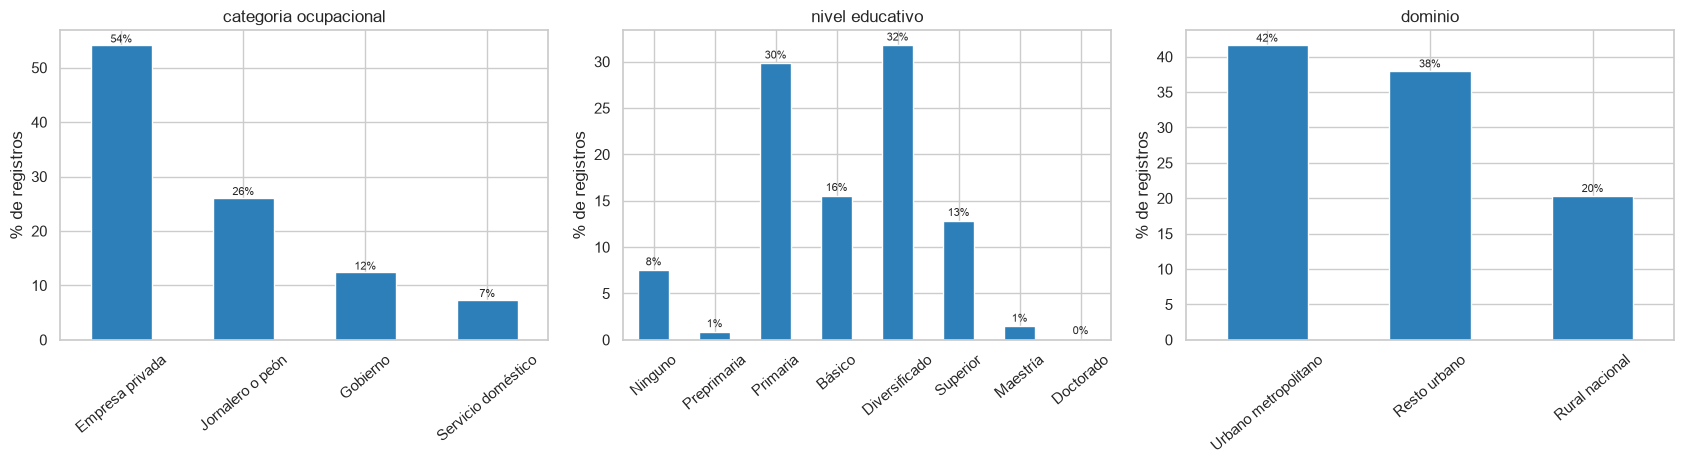

In [13]:
fig, ejes = plt.subplots(1, 3, figsize=(17, 4.8))
ORDEN_NIVEL = list(NIVEL.values()) + ["DESCONOCIDO"]
for eje, col, orden in [(ejes[0], "categoria_ocupacional", None),
                        (ejes[1], "nivel_educativo", ORDEN_NIVEL),
                        (ejes[2], "dominio", None)]:
    t = eneic_2025.groupBy(col).count().toPandas().set_index(col)["count"]
    t = t.reindex([o for o in orden if o in t.index]) if orden else t.sort_values(ascending=False)
    (100 * t / t.sum()).plot.bar(ax=eje, color="#2c7fb8")
    eje.set_title(col.replace("_", " "))
    eje.set_ylabel("% de registros")
    eje.set_xlabel("")
    eje.tick_params(axis="x", rotation=40)
    for i, v in enumerate(100 * t / t.sum()):
        eje.text(i, v + 0.5, f"{v:.0f}%", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

Más de la mitad de los asalariados trabaja en una empresa privada, seguidos por los
jornaleros o peones y los empleados de gobierno, mientras que el servicio doméstico es el grupo
más pequeño. Por nivel educativo dominan la primaria y el diversificado, y muy pocos registros
llegan a maestría o doctorado, lo que hará que las estimaciones de esos grupos sean inestables.
Por dominio, el urbano metropolitano concentra el 42 por ciento de los asalariados, el
resto urbano el 38 y el rural nacional solo el 20, lo que es coherente con que el empleo
asalariado es más frecuente en las ciudades.

### ¿El salario presenta una distribución simétrica o asimétrica? ¿Qué diferencia existe
entre su media y su mediana?

Graficamos una muestra de 5 000 registros en escala lineal y en escala logarítmica. La
escala logarítmica es solo para visualizar, el objetivo del modelado se mantiene en quetzales.

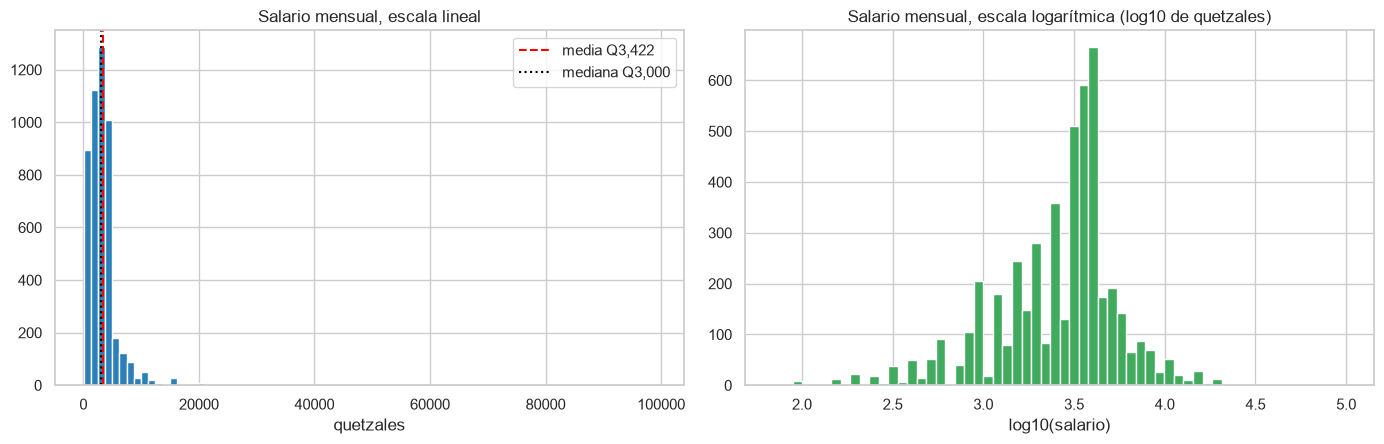

asimetría: 6.00 | media - mediana: Q422


In [14]:
muestra = (eneic_2025.sample(fraction=min(1.0, 5000 / eneic_2025.count()), seed=SEMILLA)
           .select("salario_mensual").toPandas()["salario_mensual"])
media = descriptivas.loc["Salario mensual (Q)", "media"]
mediana = descriptivas.loc["Salario mensual (Q)", "mediana"]
asim = eneic_2025.select(F.skewness("salario_mensual")).first()[0]

fig, ejes = plt.subplots(1, 2, figsize=(14, 4.6))
ejes[0].hist(muestra, bins=80, color="#2c7fb8")
ejes[0].axvline(media, color="red", ls="--", label=f"media Q{media:,.0f}")
ejes[0].axvline(mediana, color="black", ls=":", label=f"mediana Q{mediana:,.0f}")
ejes[0].set_title("Salario mensual, escala lineal")
ejes[0].set_xlabel("quetzales")
ejes[0].legend()
ejes[1].hist(np.log10(muestra), bins=60, color="#41ab5d")
ejes[1].set_title("Salario mensual, escala logarítmica (log10 de quetzales)")
ejes[1].set_xlabel("log10(salario)")
plt.tight_layout()
plt.show()
print(f"asimetría: {asim:.2f} | media - mediana: Q{media - mediana:,.0f}")

El salario es claramente asimétrico hacia la derecha. La mayoría de los registros se
concentra por debajo de Q5 000 y una cola larga de salarios altos llega hasta Q99 000, con un
coeficiente de asimetría muy por encima de cero. Por esa cola la media queda unos Q400 por
encima de la mediana, así que la mediana describe mejor el salario típico. En escala
logarítmica la distribución se ve casi simétrica, lo que confirma el sesgo multiplicativo. El
valor más alto, Q99 000, corresponde a una misma persona observada en tres trimestres, y
también hay unos pocos salarios de menos de Q100. Los conservamos, como pide el enunciado, y
tendremos en cuenta su influencia al evaluar los modelos.

### ¿Cómo varía el salario mediano entre niveles educativos y categorías
ocupacionales?

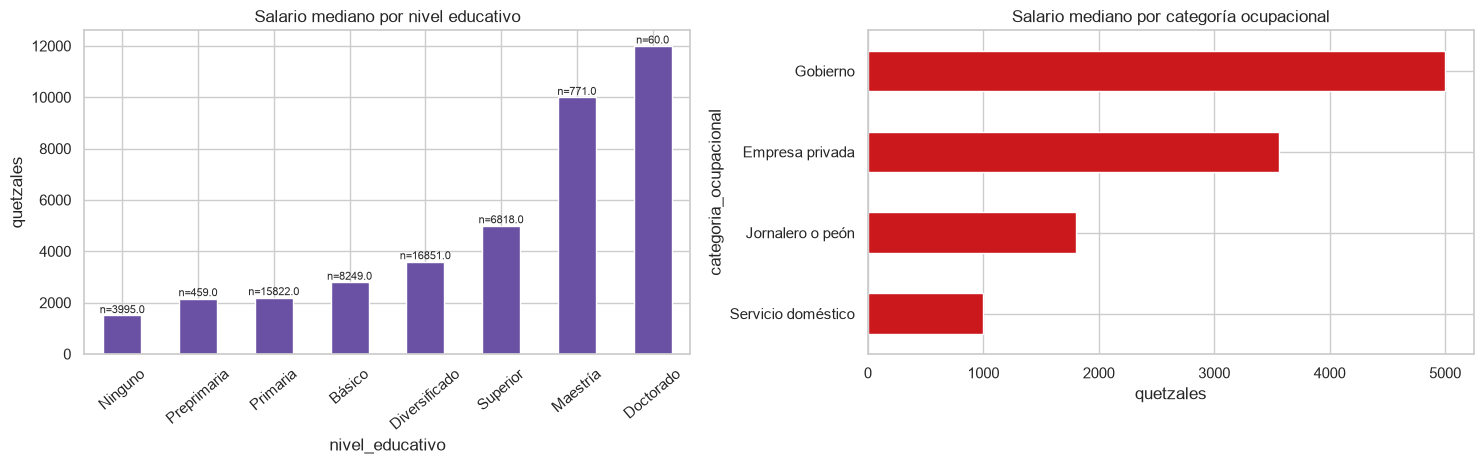

,mediana,n
nivel_educativo,,
Ninguno,1500.0,3995.0
Preprimaria,2160.0,459.0
Primaria,2200.0,15822.0
Básico,2800.0,8249.0
Diversificado,3600.0,16851.0
Superior,5000.0,6818.0
Maestría,10000.0,771.0
Doctorado,12000.0,60.0


,mediana,n
categoria_ocupacional,,
Servicio doméstico,1000.0,3906
Jornalero o peón,1800.0,13842
Empresa privada,3565.0,28702
Gobierno,5000.0,6575


In [15]:
def mediana_por(col):
    return (eneic_2025.groupBy(col)
            .agg(F.percentile_approx("salario_mensual", 0.5, 100000).alias("mediana"),
                 F.count("*").alias("n")).toPandas().set_index(col))

med_nivel = mediana_por("nivel_educativo").reindex([o for o in ORDEN_NIVEL])
med_nivel = med_nivel.dropna()
med_cat = mediana_por("categoria_ocupacional").sort_values("mediana")

fig, ejes = plt.subplots(1, 2, figsize=(15, 4.8))
med_nivel["mediana"].plot.bar(ax=ejes[0], color="#6a51a3")
ejes[0].set_title("Salario mediano por nivel educativo")
ejes[0].set_ylabel("quetzales")
ejes[0].tick_params(axis="x", rotation=40)
for i, (m, n) in enumerate(zip(med_nivel["mediana"], med_nivel["n"])):
    ejes[0].text(i, m, f"n={n}", ha="center", va="bottom", fontsize=8)
med_cat["mediana"].plot.barh(ax=ejes[1], color="#cb181d")
ejes[1].set_title("Salario mediano por categoría ocupacional")
ejes[1].set_xlabel("quetzales")
plt.tight_layout()
plt.show()
display(med_nivel, med_cat)

El salario mediano crece con el nivel educativo de forma casi escalonada. Quienes no
tienen escolaridad tienen una mediana de Q1 500 y quienes tienen primaria de Q2 200, frente a
Q3 600 del diversificado, y los niveles superior, con Q5 000, y de posgrado se separan con
claridad. Maestría y
doctorado tienen muy pocos registros, así que su mediana debe leerse con cautela. Entre
categorías, los empleados de gobierno tienen el salario mediano más alto, Q5 000, seguidos de
la empresa privada con unos Q3 600, mientras que los jornaleros, con Q1 800, y el servicio
doméstico, con Q1 000, quedan muy por debajo. Son
asociaciones descriptivas, no efectos causales de la educación o del sector.

### ¿Cómo cambian el tamaño de la muestra analítica y el salario mediano entre
trimestres?

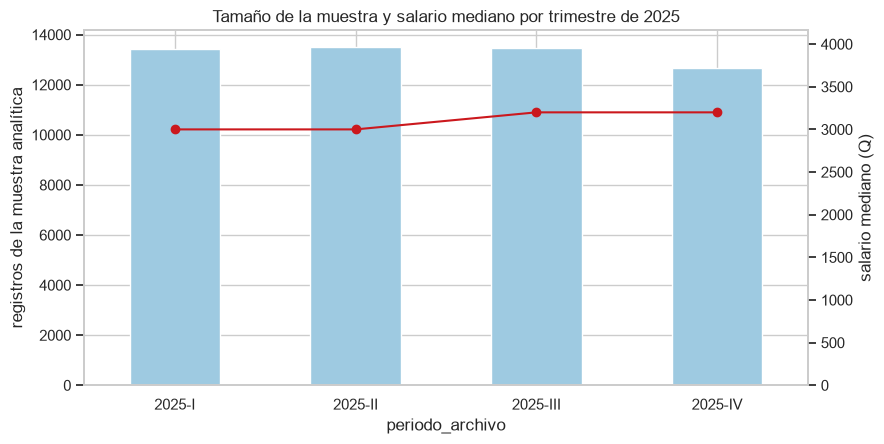

,registros,mediana,media
periodo_archivo,,,
2025-I,13419,3000.0,3315.6
2025-II,13492,3000.0,3364.6
2025-III,13450,3200.0,3469.1
2025-IV,12664,3200.0,3544.6


In [16]:
por_periodo = (eneic_2025.groupBy("periodo_archivo")
               .agg(F.count("*").alias("registros"),
                    F.percentile_approx("salario_mensual", 0.5, 100000).alias("mediana"),
                    F.mean("salario_mensual").alias("media"))
               .orderBy("periodo_archivo").toPandas().set_index("periodo_archivo"))

fig, eje1 = plt.subplots(figsize=(9, 4.6))
por_periodo["registros"].plot.bar(ax=eje1, color="#9ecae1", label="registros")
eje1.set_ylabel("registros de la muestra analítica")
eje1.tick_params(axis="x", rotation=0)
eje2 = eje1.twinx()
eje2.plot(range(len(por_periodo)), por_periodo["mediana"], "-o", color="#cb181d",
          label="salario mediano")
eje2.set_ylabel("salario mediano (Q)")
eje2.set_ylim(0, por_periodo["mediana"].max() * 1.3)
eje2.grid(False)
eje1.set_title("Tamaño de la muestra y salario mediano por trimestre de 2025")
plt.tight_layout()
plt.show()
por_periodo.round(1)

La muestra analítica es estable entre trimestres, con alrededor de 13 400 registros en
los tres primeros y una caída a unos 12 700 en el cuarto, que coincide con que ese archivo
tiene menos registros originales. El salario mediano sube de Q3 000 en los dos primeros
trimestres a Q3 200 en el tercero y el cuarto, y la media sigue la misma tendencia. Es un cambio
moderado que puede reflejar ajustes salariales en el año o diferencias en la composición de la
muestra, y no afecta la decisión de usar los cuatro trimestres en conjunto para desarrollar los
modelos.

## Ejercicio 3. Matriz de correlación

Medimos la relación lineal entre las cuatro variables numéricas de la población analítica de
2025, salario mensual, edad, antigüedad y horas habituales. Spark no calcula correlaciones
sobre columnas sueltas, así que primero las juntamos en un solo vector con VectorAssembler y
luego usamos Correlation.corr de pyspark.ml.stat. Calculamos Pearson, que mide asociación
lineal, y Spearman, que trabaja sobre los rangos y es menos sensible a la cola larga del
salario que vimos en el ejercicio 2.

In [17]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

NUM_CORR = list(VARS)
ETIQ_CORR = [VARS[c] for c in NUM_CORR]
vec_num = (VectorAssembler(inputCols=NUM_CORR, outputCol="vars_num")
           .transform(eneic_2025).select("vars_num"))

corr = {}
for metodo in ["pearson", "spearman"]:
    matriz = Correlation.corr(vec_num, "vars_num", metodo).first()[0].toArray()
    corr[metodo] = pd.DataFrame(matriz, index=ETIQ_CORR, columns=ETIQ_CORR)

for metodo, tabla in corr.items():
    print(metodo)
    display(tabla.round(3))

pearson


,Salario mensual (Q),Edad,Antigüedad (años),Horas habituales
Salario mensual (Q),1.000,0.147,0.180,0.076
Edad,0.147,1.000,0.487,-0.105
Antigüedad (años),0.180,0.487,1.000,-0.062
Horas habituales,0.076,-0.105,-0.062,1.000


spearman


,Salario mensual (Q),Edad,Antigüedad (años),Horas habituales
Salario mensual (Q),1.000,0.153,0.261,0.143
Edad,0.153,1.000,0.419,-0.120
Antigüedad (años),0.261,0.419,1.000,-0.048
Horas habituales,0.143,-0.120,-0.048,1.000


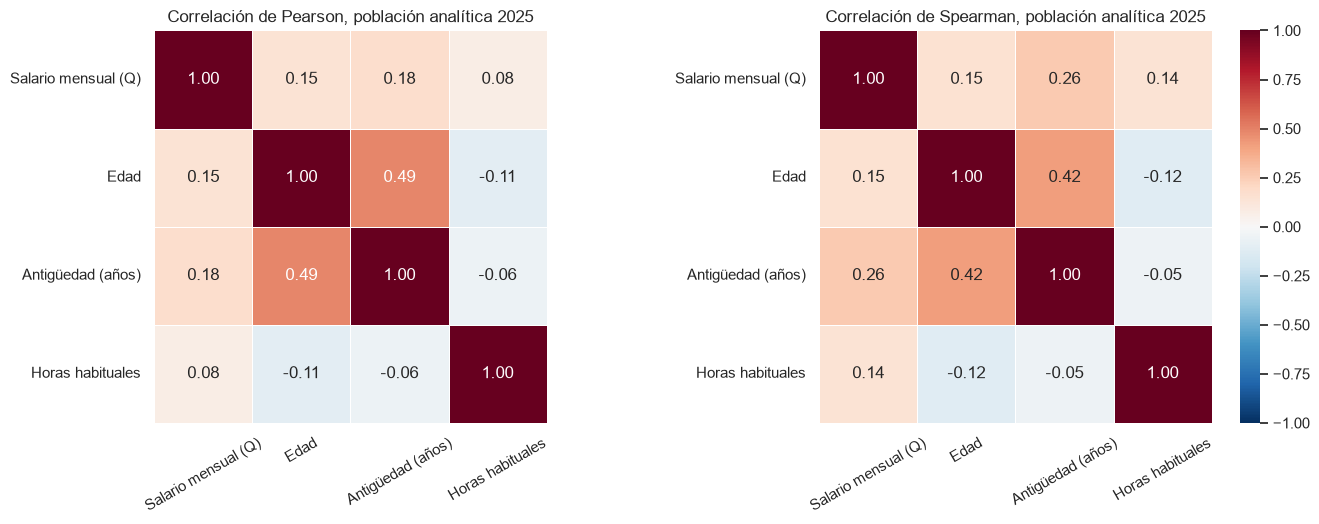

In [18]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5.4))
for eje, (metodo, tabla) in zip(ejes, corr.items()):
    sns.heatmap(tabla, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True,
                linewidths=0.5, cbar=eje is ejes[1], ax=eje)
    eje.set_title(f"Correlación de {metodo.capitalize()}, población analítica 2025")
    eje.tick_params(axis="x", rotation=30)
    eje.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

Todas las correlaciones con el salario son débiles. Con Pearson la más alta es la de la
antigüedad, 0.18, seguida de la edad con 0.15, y las horas casi no se relacionan con el salario,
0.08. Con Spearman la relación con la antigüedad sube a 0.26 y la de las horas a 0.14, porque al
usar rangos se reduce el peso de los pocos salarios muy altos. La relación entre salario y
estas variables existe y es positiva, pero no es lineal ni fuerte, así que por sí solas explican
poco de la variación del salario. En el ejercicio 2 vimos que el nivel educativo y la categoría
ocupacional separan mucho más los salarios, y esas variables no entran en esta matriz porque
son categóricas.

La correlación más alta de la matriz es entre edad y antigüedad, 0.49 con Pearson. Es una
relación en parte estructural, nadie puede llevar más años en un empleo que años de vida, y
por eso uno de nuestros filtros exigía que la antigüedad no superara la edad. No es tan alta
como para que las dos variables sean redundantes, pero conviene tenerla en cuenta al
interpretar sus efectos por separado en un modelo lineal. Las horas tienen correlaciones
negativas y muy pequeñas con la edad y la antigüedad, los trabajadores más jóvenes reportan
jornadas algo más largas. Estas asociaciones son descriptivas y no ponderadas, no indican que
trabajar más años cause un salario mayor.